# DATA266 Lab 1 - Task 1: GPT from scratch

This portable notebook works in VSCode/Jupyter or Colab. It uses no cloud-specific imports or personal paths. The model is a character-level GPT implemented from scratch with a causal multi-head attention mask. The config trains for the required 10 epochs and saves resumable checkpoints.

In [1]:
from pathlib import Path
import subprocess, sys

# When opened directly from GitHub in Colab, the notebook starts in /content
# rather than inside the repository. Clone the current repository automatically.
REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'task1_llm').is_dir() and (p / 'requirements.txt').exists()), None)
if REPO_ROOT is None:
    candidate = Path.cwd() / 'GenAI'
    if not (candidate / 'task1_llm').is_dir():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/denishatank12/GenAI.git', str(candidate)], check=True)
    REPO_ROOT = candidate
MEMBER_DIR = REPO_ROOT / 'task1_llm' / 'member_denisha'
print('Repository:', REPO_ROOT)

Repository: /content/GenAI


In [2]:
# Repair/upgrade PyTorch before importing it. This avoids stale incompatible
# torch binaries in a reused Colab runtime.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'torch', 'torchvision'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(REPO_ROOT / 'requirements.txt')], check=True)
import torch
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (GPU not available)')
data_path = REPO_ROOT / 'task1_llm' / 'data' / 'TinyStories-train.jsonl'
if not data_path.exists():
    print('TinyStories data is missing; downloading the approved train split.')
    subprocess.run([sys.executable, 'reproducibility/prepare_data.py', '--task', 'task1', '--out', str(REPO_ROOT)], cwd=REPO_ROOT, check=True)
print('Dataset:', data_path, data_path.stat().st_size, 'bytes')
assert data_path.exists() and data_path.stat().st_size > 0

Device: Tesla T4
TinyStories data is missing; downloading the approved train split.
Dataset: /content/GenAI/task1_llm/data/TinyStories-train.jsonl 1963864953 bytes


## Smoke test

This must pass before training. It checks forward/backward execution, causal masking, finite gradients, and generation without downloading data or writing results.

In [3]:
subprocess.run([sys.executable, 'src/smoke_test.py'], cwd=MEMBER_DIR, check=True)

CompletedProcess(args=['/usr/bin/python3', 'src/smoke_test.py'], returncode=0)

## Train, resume, evaluate, and validate

Run this cell once. If the runtime disconnects, run it again; the latest checkpoint is resumed automatically. All required metrics, curves, samples, failure analysis, raw log, and manifest are produced by the runner.

In [4]:
subprocess.run([sys.executable, 'run_task1.py'], cwd=MEMBER_DIR, check=True)

CompletedProcess(args=['/usr/bin/python3', 'run_task1.py'], returncode=0)

train_loss,validation_loss,perplexity,bits_per_character,generalization_gap,top1_next_character_accuracy,final_grad_norm,max_grad_norm,gradient_nan_count,parameter_count,training_tokens_per_second,generation_tokens_per_second,peak_memory_mb,training_time_seconds,device,vocabulary_size,distinct_1,distinct_2,distinct_3,repeated_4gram_rate
0.712783145977165,0.6822180123602506,1.9782606763534245,0.9842325432372591,-0.030565133616914375,0.782189716882634,0.2318199872970581,0.28718411922454834,0,3250688,224657.93113441812,268.03633555696325,408.31884765625,3995.2879271507263,cuda,114,0.10802469135802469,0.4582043343653251,0.7360248447204969,0.1526479750778816

Report: /content/GenAI/task1_llm/member_denisha/results.md


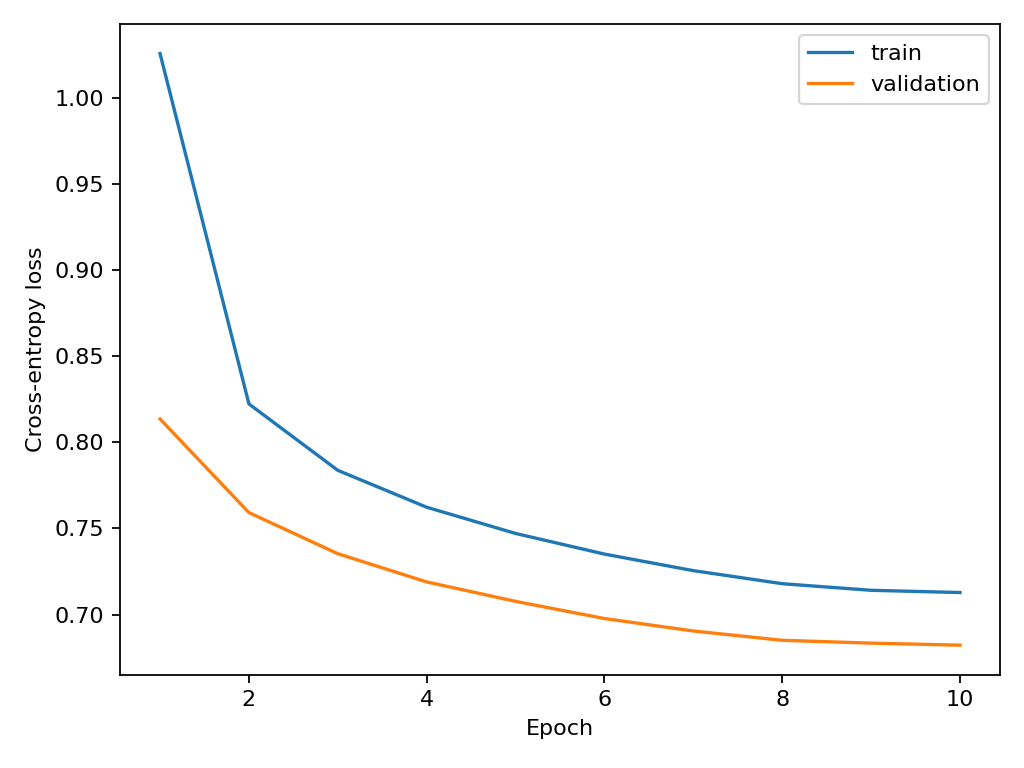

In [5]:
from IPython.display import Image, display
curve = MEMBER_DIR / 'outputs' / 'loss_curves.png'
print((MEMBER_DIR / 'outputs' / 'metrics.csv').read_text())
print('Report:', MEMBER_DIR / 'results.md')
if curve.exists(): display(Image(filename=str(curve)))

In [8]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

repo = Path("/content/GenAI")
zip_path = Path("/content/task1_denisha_final_artifacts.zip")

required = [
    repo / "task1_llm/member_denisha/results.md",
    repo / "task1_llm/member_denisha/failure_analysis.md",
    repo / "task1_llm/member_denisha/outputs",
    repo / "task1_llm/member_denisha/checkpoints",
    repo / "reproducibility/raw_logs/task1_denisha.log",
    repo / "reproducibility/manifests/task1_denisha.json",
]

with ZipFile(zip_path, "w", ZIP_DEFLATED) as archive:
    for item in required:
        if item.is_file():
            archive.write(item, item.relative_to(repo))
        elif item.is_dir():
            for file in item.rglob("*"):
                if file.is_file():
                    archive.write(file, file.relative_to(repo))

print("Created:", zip_path)
print("Size:", zip_path.stat().st_size / 1e6, "MB")

files.download(str(zip_path))

Created: /content/task1_denisha_final_artifacts.zip
Size: 403.594506 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Task 1 submission evidence

Submit/reference these generated artifacts: `member_denisha/results.md`, `failure_analysis.md`, `outputs/metrics.csv`, `outputs/history.json`, `outputs/loss_curves.png`, `outputs/samples.json`, the raw log, the manifest, and the final checkpoint. The failure analysis contains three actual generated-temperature cases.